# Práctica 2 — Análisis Exploratorio de Datos

En este notebook realizarás un **análisis exploratorio de datos (EDA)** sobre un
dataset de 240 estrellas clasificadas en 6 tipos.

**Dataset:** [Stars Dataset — Kaggle](https://www.kaggle.com/datasets/waqi786/stars-dataset)

## Instrucciones generales
- Cada sección tiene celdas marcadas con `# tu código aquí` — ahí debes escribir tu solución.
- Lee las instrucciones en cada celda de markdown **antes** de escribir el código.
- Consulta los enlaces a la documentación oficial para entender los parámetros de cada función.
- Ejecuta el notebook completo **sin errores** antes de hacer commit (`Kernel → Restart & Run All`).

## Contenido
1. [Importar librerías](#1.-Importar-librerías)
2. [Cargar los datos](#2.-Cargar-los-datos)
3. [Exploración inicial](#3.-Exploración-inicial)
4. [Distribución por tipo de estrella](#4.-Distribución-por-tipo-de-estrella)
5. [Temperatura por tipo](#5.-Temperatura-por-tipo-de-estrella)
6. [Luminosidad vs Temperatura](#6.-Luminosidad-vs-Temperatura)
7. [Estadísticas con NumPy](#7.-Estadísticas-con-NumPy)
8. [Diagrama Hertzsprung-Russell](#8.-Diagrama-Hertzsprung-Russell)


---
## Configuración del ambiente

Este proyecto usa **Poetry** para gestionar las dependencias. Antes de abrir el notebook
ejecuta estos comandos **desde la carpeta `practica2_analisis_datos/`**:

```bash
poetry install
poetry run jupyter notebook
```

---
## 1. Importar librerías

Importa las cuatro librerías con sus **alias convencionales**.
Estos alias son estándares en la comunidad — siempre se usan así:

| Librería | Alias | ¿Para qué sirve? | Documentación |
|---|---|---|---|
| `numpy` | `np` | Operaciones matemáticas vectorizadas sobre arrays | [numpy.org/doc/stable](https://numpy.org/doc/stable/user/whatisnumpy.html) |
| `pandas` | `pd` | Análisis y manipulación de datos tabulares (DataFrames) | [pandas.pydata.org/docs](https://pandas.pydata.org/docs/getting_started/index.html) |
| `matplotlib.pyplot` | `plt` | Visualización de datos (gráficas de bajo nivel) | [matplotlib.org/tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| `seaborn` | `sns` | Visualización estadística de alto nivel (sobre matplotlib) | [seaborn.pydata.org/tutorial](https://seaborn.pydata.org/tutorial.html) |

**Sintaxis:** `import librería as alias`

In [125]:
# Importa las cuatro librerías con sus alias convencionales
# tu código aquí
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Una vez que las importes, descomenta estas líneas para verificar las versiones:
print(f'numpy   {np.__version__}')
print(f'pandas  {pd.__version__}')
print(f'seaborn {sns.__version__}')

numpy   2.3.5
pandas  2.3.3
seaborn 0.13.2


---
## 2. Cargar los datos

Usa [`pd.read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
para leer el archivo CSV y cargarlo en un **DataFrame** de pandas.

- Revisa la documentación: ¿qué parámetro recibe `read_csv`? ¿qué devuelve?
- El archivo se encuentra en `'../data/star_dataset.csv'` (relativo a la carpeta `notebooks/`)
- Guarda el resultado en una variable llamada `stars`
- Después usa [`.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
  para mostrar las primeras 5 filas

In [126]:
# Carga el archivo CSV con pd.read_csv() y guárdalo en 'stars'
# tu código aquí

stars = pd.read_csv(r'C:\Users\maria\OneDrive\Documents\F12-Programacion\F12-Programacion2\practicas\phyton\analisis_datos\data\star_dataset.csv' )

# Muestra las primeras 5 filas del DataFrame
# tu código aquí
stars.head()

,Name,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K),Spectral Class
0,Altair,16.594171,9.979192,1.632650,7509.294247,A7V
1,Deneb,2600.490723,196002.627856,202.970526,8503.284796,A2Ia
2,Barnard's Star,6.052616,4.893716,0.222711,3165.959639,M4Ve
3,Polaris,322.601002,2196.241934,37.546813,6048.326915,F7Ib
4,Barnard's Star,5.902392,-1.496486,0.192359,3130.602069,M4Ve


---
## 3. Exploración inicial

Antes de analizar datos siempre hay que entender qué tenemos.

**Celda 3a** — Imprime la información básica del DataFrame:
1. **Dimensiones** con [`.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html)
   — devuelve una tupla `(filas, columnas)`
2. **Nombres de columnas** con [`.columns.tolist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)
3. **Tipos de datos** con [`.dtypes`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)
   — indica si cada columna es `int64`, `float64` o `object` (texto)

**Celda 3b** — Obtén estadísticas descriptivas con
[`.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).
Fíjate en la media, desviación estándar, mínimo y máximo de cada columna numérica.

**Celda 3c** — Verifica si hay valores nulos con
[`.isnull()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)
seguido de `.sum()`. En un dataset limpio todos los valores deben ser 0.

In [127]:
# Imprime: dimensiones, nombres de columnas y tipos de datos
# tu código aquí
print("Dimensiones del dataset:", stars.shape)
print("Nombres de las columnas:", stars.columns.tolist())
print("Tipos de datos por columna:")
print(stars.dtypes)

# 3a: Estructura
stars.shape
stars.dtypes
print(stars.shape)
print(stars.columns.tolist())
print(stars.dtypes)

# 3b: Estadísticas
stars.describe()

# 3c: Valores nulos
stars.isnull().sum()

Dimensiones del dataset: (1000, 6)
Nombres de las columnas: ['Name', 'Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)', 'Spectral Class']
Tipos de datos por columna:
Name                  object
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class        object
dtype: object
(1000, 6)
['Name', 'Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)', 'Spectral Class']
Name                  object
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class        object
dtype: object


Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64

In [128]:
# Obtén el resumen estadístico de las columnas numéricas
# tu código aquí
stars.describe()

,Distance (ly),Luminosity (L/Lo),Radius (R/Ro),Temperature (K)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,295.505327,19644.909442,86.960696,9983.486779
std,541.478403,42223.595017,213.850005,7906.973529
min,3.877798,-4.993141,0.068087,2750.183163
25%,11.716853,10.441039,1.664479,3940.020856
50%,52.031435,171.097809,5.845444,7379.007975
75%,322.865874,10500.577117,33.719778,12055.975095
max,2600.490723,196004.854081,887.097936,28044.279272


In [129]:
# Cuenta los valores nulos por columna
# tu código aquí
stars.isnull().sum()

Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64

---
## 4. Distribución por tipo de estrella

**Celda 4a** — Usa
[`.value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
sobre la columna `'Spectral Class'` para contar cuántas estrellas hay de cada tipo.
Guarda el resultado en una variable llamada `conteo`.

> Pista: accede a una columna del DataFrame con `df['nombre_columna']`, que devuelve una **Serie**.
> `.value_counts()` es un método de Series.

**Celda 4b** — Crea una **gráfica de barras** de `conteo`:
1. La línea `plt.figure(figsize=(8, 4))` ya está incluida — no la borres
2. Llama [`.plot(kind='bar')`](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html)
   sobre `conteo`, usando `color='steelblue'` y `edgecolor='black'`
3. Agrega título con `plt.title(...)`, etiquetas con `plt.xlabel(...)` y `plt.ylabel(...)`
4. Rota las etiquetas del eje X: `plt.xticks(rotation=30, ha='right')`

In [130]:
# Cuenta las estrellas por tipo y guarda el resultado en 'conteo'
# tu código aquí
#Aquí es donde contamos cuantas estrellas hay por clase espectral
conteo=stars['Spectral Class'].value_counts()
print(conteo)

Spectral Class
A7V         74
A1V         73
A9II        48
M3.5V       45
B1III       45
M2Iab       44
G8III       39
M4Ve        38
A0V         38
K1.5III     38
B2III       37
M7IIIe      37
B0Ia        36
G2V         36
F7Ib        35
B1III-IV    32
A3V         31
F5IV-V      30
B0.5IV      30
B6Vep       29
M2.1V       27
M1.5Iab     26
B7V         26
A2Ia        25
K1V         24
M6V         22
K5III       18
B8Ia        17
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>

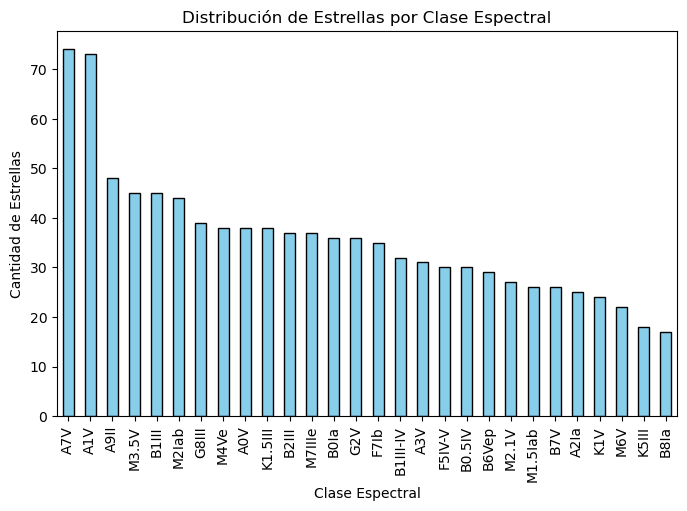

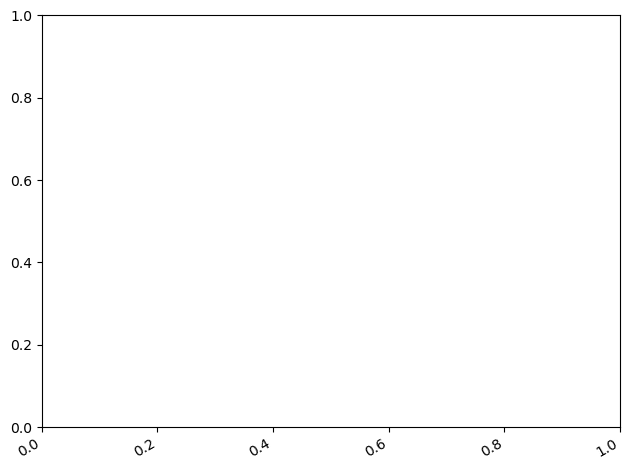

In [131]:
plt.figure(figsize=(8, 4))

# Crea la gráfica de barras con conteo.plot(kind='bar', color=..., edgecolor=...)
# tu código aquí

# Creamos una gráfica de barras con el conteo anterior
plt.figure(figsize=(8, 5))
conteo.plot(kind='bar', color='skyblue', edgecolor='black')

# Agrega título y etiquetas de ejes
# tu código aquí

plt.title('Distribución de Estrellas por Clase Espectral')
plt.xlabel('Clase Espectral')
plt.ylabel('Cantidad de Estrellas')
plt.show()

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Temperatura por tipo de estrella

En esta sección calcularás la temperatura media de dos formas distintas para comparar.

**Celda 5a — Ciclo `for` (enfoque manual):**

Primero filtra el DataFrame para obtener solo las estrellas de tipo `'A7V'`:
```python
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]
```
Luego recorre la columna `'Temperature (K)'` del DataFrame filtrado con un `for`,
acumula la `suma` y el `conteo` (`n`), y calcula la media como `suma / n`.

Consulta [cómo filtrar un DataFrame por valor](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)
si necesitas orientación sobre la sintaxis de filtrado.

**Celda 5b — Pandas `.groupby()` (enfoque vectorizado):**

Usa [`.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)
para calcular la media de **todas las clases a la vez** en una sola línea:
```python
df.groupby('columna_categorica')['columna_numerica'].mean()
```
Ordena de mayor a menor con `.sort_values(ascending=False)`. Guarda en `temp_por_tipo`.
Compara el resultado de `'A7V'` con el valor que obtuviste con el `for`.

**Celda 5c — Boxplot:**

Usa [`sns.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) con
`data=stars`, `x='Spectral Class'`, `y='Temperature (K)'`, `order=orden`.

In [132]:
# ── Enfoque 1: ciclo for ──────────────────────────────────────────────────────
tipo_objetivo = 'A7V'

# Paso 1: filtra el DataFrame para obtener solo las estrellas de tipo_objetivo (clase espectral)
# filtrado = ...
# tu código aquí
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]
print(filtrado)
suma_temperaturas = 0
contador= 0

# Paso 2: recorre filtrado['Temperature (K)'] con un for
# acumula la suma y el conteo (n)
# tu código aquí
# Ciclo for para sumar manualmente
for temp in filtrado['Temperature (K)']:
    suma_temperaturas = suma_temperaturas + temp  # Vamos sumando cada valor
    contador = contador + 1                       # Contamos cuántas van


# Calcula la media y guárdala en media_manual
# media_manual = suma / n
# tu código aquí
# Calculamos la media solo si encontramos al menos una estrella
if contador > 0:
    media_manual = suma_temperaturas / contador
    print(f"La temperatura media manual para {tipo_objetivo} es: {media_manual:.2f} K")
else:
    media_manual = 0
    print(f"ADVERTENCIA: No se encontraron estrellas clase {tipo_objetivo} en el dataset.")   
print(f'TEMPERATURA MEDIA (for loop) : {media_manual:,.1f} K')


       Name  Distance (ly)  Luminosity (L/Lo)  Radius (R/Ro)  Temperature (K)  \
0    Altair      16.594171           9.979192       1.632650      7509.294247   
11   Altair      16.324632          10.457079       1.638568      7554.538238   
32   Altair      16.977835           8.978259       1.681768      7546.776074   
41   Altair      16.481724          10.654505       1.697977      7557.224465   
82   Altair      17.004753          15.509654       1.574136      7589.018862   
..      ...            ...                ...            ...              ...   
974  Altair      16.502834          15.008535       1.537144      7531.390715   
984  Altair      17.154742           6.975772       1.548312      7537.641975   
989  Altair      17.111919          10.391013       1.609587      7504.094813   
990  Altair      16.874372           5.998471       1.559794      7561.789883   
993  Altair      17.121544          11.776187       1.635310      7555.418080   

    Spectral Class  
0     

### Comparación: `for` vs. pandas

Con el ciclo `for` calculaste la media de **una sola clase espectral** en varias líneas.
Ahora verás cómo pandas obtiene la media de **todas las clases a la vez** en una sola línea.

Cuando termines la celda 5b, verifica que el resultado de `A7V`
coincida con el valor que obtuviste con el `for`.

In [133]:
# ── Enfoque 2: pandas groupby ─────────────────────────────────────────────────
# Calcula la temperatura promedio por tipo con groupby
# Ordena de mayor a menor y guarda en temp_por_tipo
# tu código aquí
# Groupby agrupa todas las estrellas por clase y saca el promedio (mean) de golpe
temp_por_tipo=stars.groupby('Spectral Class')['Temperature (K)'].mean()
# Cálculo vectorizado para todos los tipos

print('Temperatura promedio por clase espectral (K):')
print(temp_por_tipo)
print()

# Imprime una línea de verificación comparando media_manual con el valor de groupby para 'A7V'
# tu código aquí
print(f"\nVerificación:")
print(f"Media manual calculada: {media_manual:.2f} K")

# Usamos .get() para evitar el KeyError si 'A7V' no existe
valor_pandas = temp_por_tipo.get(tipo_objetivo, 0)
print(f"Media con Pandas para {tipo_objetivo}: {valor_pandas:.2f} K")


Temperatura promedio por clase espectral (K):
Spectral Class
A0V          9607.458129
A1V         10136.022204
A2Ia         8516.840653
A3V          8584.693288
A7V          7550.178313
A9II         7349.223744
B0.5IV      28001.166630
B0Ia        27502.303666
B1III       25001.131122
B1III-IV    25403.170510
B2III       22600.139741
B6Vep       15003.610593
B7V         12462.119029
B8Ia        12092.293145
F5IV-V       6520.419327
F7Ib         6020.393400
G2V          5797.996506
G8III        4939.733287
K1.5III      4280.090548
K1V          5261.645715
K5III        3923.614977
M1.5Iab      3499.130207
M2.1V        3408.914115
M2Iab        3502.196868
M3.5V        2802.627176
M4Ve         3136.076002
M6V          2795.196060
M7IIIe       2914.515688
Name: Temperature (K), dtype: float64


Verificación:
Media manual calculada: 7550.18 K
Media con Pandas para A7V: 7550.18 K


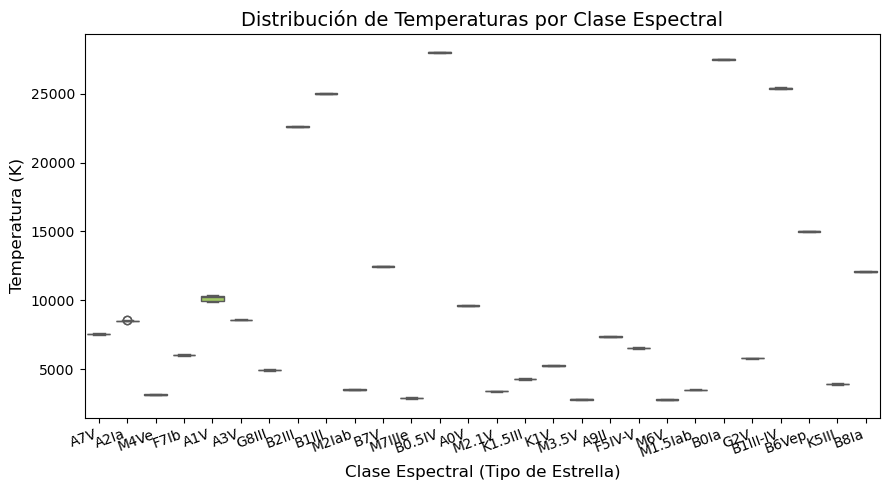

In [134]:
plt.figure(figsize=(9, 5))
orden = temp_por_tipo.index   # orden de mayor a menor temperatura

# Crea el boxplot con sns.boxplot(data=..., x=..., y=..., order=...)
# tu código aquí
# 2. Creamos el diagrama de cajas usando Seaborn
# x: las categorías (clases), y: lo que queremos medir (temperatura)
sns.boxplot(x='Spectral Class', y='Temperature (K)', data=stars, 
            palette='Set2', hue='Spectral Class', legend=False)
# Agrega título y etiquetas de ejes
# tu código aquí
plt.title("Distribución de Temperaturas por Clase Espectral", fontsize=14)
plt.xlabel("Clase Espectral (Tipo de Estrella)", fontsize=12)
plt.ylabel("Temperatura (K)", fontsize=12)

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Luminosidad vs Temperatura

La luminosidad varía en muchos órdenes de magnitud (de 0.00008 a 849 420 L/Lo),
por eso necesitamos **escala logarítmica** en el eje Y.

Usa [`sns.scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)
con los siguientes parámetros (revisa la documentación para entender cada uno):
- `data=stars` — el DataFrame
- `x='Temperature (K)'` — temperatura en el eje X
- `y='Luminosity (L/Lo)'` — luminosidad en el eje Y
- `hue='Spectral Class'` — colorea los puntos según la clase espectral
- `style='Spectral Class'` — usa un marcador diferente por clase espectral
- `s=60` — tamaño de los puntos

Después de crear el plot, aplica escala logarítmica al eje Y con
[`plt.yscale('log')`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html).

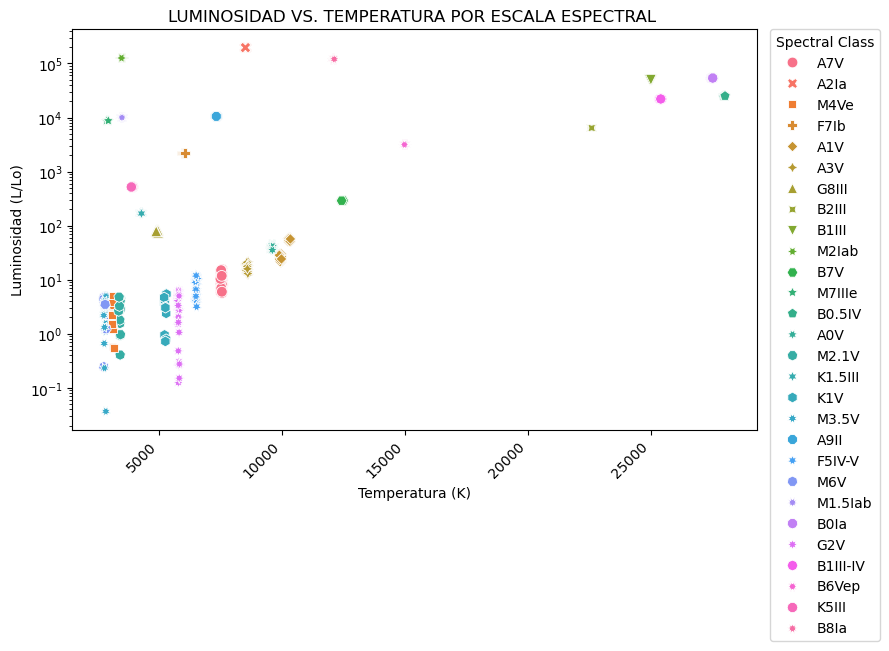

In [135]:
plt.figure(figsize=(9, 6))

# Crea el scatter plot con sns.scatterplot(...)
# tu código aquí
# Crea el scatter plot con sns.scatterplot(...)
# tu código aquí
sns.scatterplot(data=stars, 
                x='Temperature (K)', 
                y='Luminosity (L/Lo)', 
                hue='Spectral Class', 
                style='Spectral Class', 
                s=60)


# Aplica escala logarítmica al eje Y
# tu código aquí
plt.yscale('log')

# Agrega título, etiquetas de ejes y leyenda
# tu código aquí

plt.legend(title='Spectral Class', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.title('LUMINOSIDAD VS. TEMPERATURA POR ESCALA ESPECTRAL ')
plt.xlabel('Temperatura (K)')
plt.ylabel('Luminosidad (L/Lo)')

plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()


---
## 7. Estadísticas con NumPy

NumPy opera sobre **arrays completos** sin ciclos `for`. Por ejemplo,
`np.mean(arr)` calcula la media de todos los elementos de `arr` de una sola vez.

**Celda 7a** — Extrae los arrays con `.values` y calcula estadísticas:
- Extrae: `temperaturas = stars['Temperature (K)'].values`
- Extrae: `radios = stars['Radius (R/Ro)'].values`
- Verifica el tipo con `type(temperaturas)`
- Calcula usando estas funciones de [`numpy.statistics`](https://numpy.org/doc/stable/reference/routines.statistics.html):
  - [`np.mean(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) — media
  - [`np.median(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.median.html) — mediana
  - [`np.std(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.std.html) — desviación estándar
  - [`np.min(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amin.html) y [`np.max(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amax.html)

**Celda 7b** — Percentiles y conversión vectorizada:
- Usa [`np.percentile(arr, q)`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)
  con `q=[25, 50, 75, 90]` para calcular los 4 percentiles de `radios` de una vez
- Convierte `temperaturas` de Kelvin a Celsius **sin usar ciclo `for`**:
  `celsius = temperaturas - 273.15` (operación vectorizada)

In [136]:
# Extrae los arrays NumPy con .values
# tu código aquí
temperaturas = stars['Temperature (K)'].values
radios = stars['Radius (R/Ro)'].values
tipo_temperaturas = type(temperaturas)
# Imprime el tipo del array
# tu código aquí
print(f"Tipo de temperaturas {tipo_temperaturas}")

# Calcula e imprime: media, mediana, desv. estándar, mínima y máxima de temperaturas
# tu código aquí
# Calculamos los estadísticos básicos usando funciones de NumPy
media = np.mean(temperaturas)
mediana = np.median(temperaturas)
desviacion = np.std(temperaturas)
minima = np.min(temperaturas)
maxima = np.max(temperaturas)

# Imprimimos los resultados con 2 decimales (.2f)
print(f"Estadísticas Globales de Temperatura:")
print(f" - Media: {media:.2f} K")
print(f" - Mediana: {mediana:.2f} K")
print(f" - Desviación Estándar: {desviacion:.2f} K")
print(f" - Mínima: {minima:.2f} K")
print(f" - Máxima: {maxima:.2f} K")


Tipo de temperaturas <class 'numpy.ndarray'>
Estadísticas Globales de Temperatura:
 - Media: 9983.49 K
 - Mediana: 7379.01 K
 - Desviación Estándar: 7903.02 K
 - Mínima: 2750.18 K
 - Máxima: 28044.28 K


In [137]:
niveles = [25, 50, 75, 90]

# Calcula los percentiles del radio estelar con np.percentile(radios, niveles)
# tu código aquí
# Esto sirve para ver cómo se distribuye el tamaño de las estrellas
percentiles_radio = np.percentile(stars['Radius (R/Ro)'], [25, 50, 75])

print(f"Rango de Temperaturas: Min {minima} K - Max {maxima} K")
print(f"Percentiles del Radio (25%, 50%, 75%): {percentiles_radio}")

# Imprime cada percentil usando un ciclo for y zip(niveles, p)
# tu código aquí

# El ciclo for con zip para imprimir ordenadamente
# zip une el nivel (25, 50...) con su resultado correspondiente
for nivel, valor in zip(niveles, percentiles_radio):
    print(f"Percentil {nivel}% del Radio: {valor:.2f} R/Ro")

# Convierte temperaturas de Kelvin a Celsius de forma vectorizada (sin for)
# celsius = ...
# tu código aquí
# Esta es la operación vectorizada: se aplica a todo el array al mismo tiempo
celsius_array = temp_array - 273.15

# Imprime las primeras 5 temperaturas en K y en C para comparar
# (usa np.round para redondear a 1 decimal)
# tu código aquí
print(f"Primeras 5 temperaturas en Celsius: {np.round(celsius_array[:5], 1)}C")

Rango de Temperaturas: Min 2750.18316322717 K - Max 28044.279271635794 K
Percentiles del Radio (25%, 50%, 75%): [ 1.6644792   5.84544356 33.71977799]
Percentil 25% del Radio: 1.66 R/Ro
Percentil 50% del Radio: 5.85 R/Ro
Percentil 75% del Radio: 33.72 R/Ro
Primeras 5 temperaturas en Celsius: [2794.8 2768.8 2326.8 2526.8 1665.8]C


---
## 8. Diagrama Hertzsprung-Russell

El diagrama H-R es el gráfico más importante en astronomía estelar.
Relaciona temperatura con luminosidad y revela la estructura evolutiva de las estrellas.

Este diagrama tiene **dos particularidades** que debes implementar:
1. **Ambos ejes logarítmicos**: `plt.xscale('log')` y `plt.yscale('log')`
2. **Eje X invertido** (las más calientes a la izquierda): `plt.gca().invert_xaxis()`

**Estructura del código** (el inicio ya está dado, completa las partes marcadas):

```python
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))   # paleta de colores
mapa    = dict(zip(tipos, colores))                # tipo -> color

for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'],
                grupo['Luminosity (L/Lo)'],
                label=tipo, color=mapa[tipo], s=40, alpha=0.8)
```

Parámetros de [`plt.scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
que debes entender: `x`, `y`, `label`, `color`, `s` (tamaño), `alpha` (transparencia).

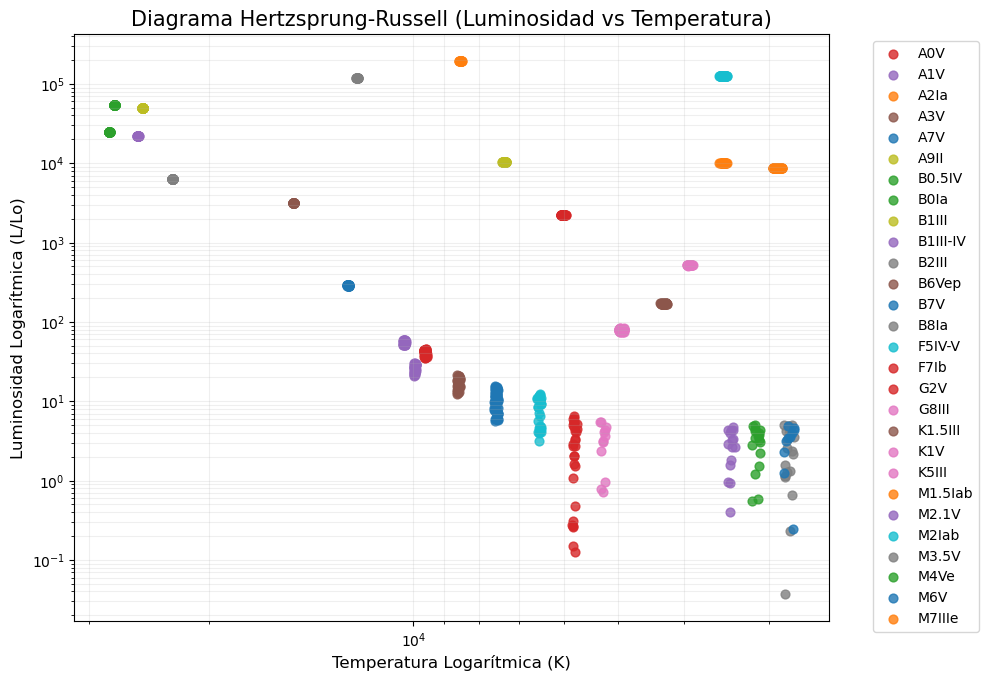

In [138]:
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))
mapa    = dict(zip(tipos, colores))

plt.figure(figsize=(10, 7))

# Itera con stars.groupby('Spectral Class') y crea un plt.scatter() por cada tipo
# tu código aquí
# 2. Creamos un Scatter Plot (Gráfico de puntos)
# hue='Spectral Class' le pone un color diferente a cada tipo de estrella
for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'],
                grupo['Luminosity (L/Lo)'],
                label=tipo, color=mapa[tipo], s=40, alpha=0.8)

# Aplica escala logarítmica en ambos ejes (xscale y yscale)
# tu código aquí
# Se usa porque los brillos (luminosidad) varían por millones
plt.xscale('log')
plt.yscale('log')

# Invierte el eje X con plt.gca().invert_xaxis()
# tu código aquí
# En este diagrama, lo más caliente SIEMPRE va a la izquierda
plt.gca().invert_xaxis()

# Agrega: título, etiquetas de ejes, leyenda y grid
# tu código aquí
plt.title("Diagrama Hertzsprung-Russell (Luminosidad vs Temperatura)", fontsize=15)
plt.xlabel("Temperatura Logarítmica (K)", fontsize=12)
plt.ylabel("Luminosidad Logarítmica (L/Lo)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2) # Cuadrícula suave
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [139]:
print("\n" + "="*40)
print("¡PRÁCTICA COMPLETADA EXITOSAMENTE!")
print("="*40)


¡PRÁCTICA COMPLETADA EXITOSAMENTE!
